<a href="https://colab.research.google.com/github/pickle-lotus0976/Learning/blob/main/cnn_fpga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get update && sudo apt-get upgrade -y

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,293 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,640 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [61.5 kB]
Get:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease

In [2]:
"""
In this section, I create a JSON file from my Kaggle API key to directly load the dataset
from Kaggle.
"""
import os, json

kaggle_info = {
    "username": "shubhrakamalsaha",
    "key": "KGAT_e148f7322acc228c411bfafd0d06e34e" # my API key
}

os.makedirs("/root/.kaggle", exist_ok=True) # We'll create a dedicated hidden directory for the JSON file

with open("/root/.kaggle/kaggle.json", "w") as f: # Create a new file called kaggle.json
    json.dump(kaggle_info, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600) # Set appropriate permsissions

print("kaggle.json file created successfully.")

kaggle.json file created successfully.


In [3]:
"""
I am installing all the Python libraries at once.
We can install them one at a time as well
"""
!pip install kaggle # Install Kaggle
!pip install torchinfo # Install torchinfo (we'll use it later)

In [4]:
!kaggle datasets download -d iroldan/real-doppler-raddar-database # Download the dataset directly from Kaggle
!unzip real-doppler-raddar-database.zip -d /content/dataset # Unzip it and store it in /content/dataset directory

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/data/People/11-23f/015.csv  
  inflating: /content/dataset/data/People/11-23f/016.csv  
  inflating: /content/dataset/data/People/11-23f/017.csv  
  inflating: /content/dataset/data/People/11-23f/018.csv  
  inflating: /content/dataset/data/People/11-23f/019.csv  
  inflating: /content/dataset/data/People/11-23f/020.csv  
  inflating: /content/dataset/data/People/11-23f/021.csv  
  inflating: /content/dataset/data/People/11-23f/022.csv  
  inflating: /content/dataset/data/People/11-23f/023.csv  
  inflating: /content/dataset/data/People/11-23f/024.csv  
  inflating: /content/dataset/data/People/11-23f/025.csv  
  inflating: /content/dataset/data/People/11-23f/026.csv  
  inflating: /content/dataset/data/People/11-23f/027.csv  
  inflating: /content/dataset/data/People/11-23f/028.csv  
  inflating: /content/dataset/data/People/11-23f/029.csv  
  inflating: /content/dataset/data/People/11-23f/030.csv  
  inf

In [5]:
"""
Once again, I am importing all the necessary libraries at once here
so that we don't have to import them one by one.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm # for providing progress bars (why? they're cool, that's why)
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import seaborn as sns

In [6]:
torch.manual_seed(42)

In [7]:
"""
Here we'll see what is actually there in our dataset.
We'll navigate through the sub directories and take a look at the actual CSV files
This is to better understand the format of our data
"""
dataset_path = "/content/dataset"

print("Class directories:\n")
for item in os.listdir(dataset_path):
  item_path = os.path.join(dataset_path, item)
  if os.path.isdir(item_path):
    print(f"{item}")

"""
We'll do a simple exercise.
We'll take a class directory and we'll see what is inside it.
And list all the subdirectories of this class.
Then we'll take a look at one CSV file to see the values.
"""
drones_path = os.path.join(dataset_path, "Drones") # we will take the drones folder (because drones are cool)
drones_subdirs = os.listdir(drones_path) # then we will store the path of subdirectories
print(f"Here are all the {len(drones_subdirs)} subdirectories")
# print all the subdirectories of this class
for item in drones_subdirs:
  print(f"- {item}")

any_subdir = os.path.join(drones_path, drones_subdirs[2]) # we'll take the third subdirectory as an example
csv_files = [i for i in os.listdir(any_subdir) if i.endswith('.csv')]
print(f"There are total {len(csv_files)} in {drones_subdirs[2]} subdirectory")

sample_file = os.path.join(any_subdir, csv_files[1])
sample_df = pd.read_csv(sample_file, header=None)
print(f"Shape of the sample CSV file {sample_df.shape}\n")
sample_df.head()

Class directories:

People
data
Cars
Drones
Here are all the 21 subdirectories
- 15-33
- 13-21
- 15-47
- 15-16
- 15-24
- 15-30
- 15-36
- 15-44
- 12-34
- 16-15
- 12-41
- 16-11
- 15-38
- 15-50
- 16-09
- 15-42
- 13-48
- 15-18
- 15-21
- 13-14
- 16-17
There are total 195 in 15-47 subdirectory
Shape of the sample CSV file (11, 61)



,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,-108.80,-118.05,-111.21,-108.98,-109.27,-114.98,-108.53,-117.39,-107.01,-112.69,...,-107.24,-108.82,-112.34,-114.70,-110.11,-109.07,-108.31,-105.23,-102.96,-103.91
1,-112.40,-113.45,-110.36,-110.05,-109.40,-111.23,-107.63,-110.32,-107.73,-108.45,...,-106.35,-109.94,-121.59,-113.40,-115.86,-109.31,-104.98,-104.31,-107.38,-110.10
2,-110.10,-112.10,-111.22,-113.14,-118.32,-109.68,-106.80,-109.68,-112.24,-108.50,...,-107.83,-108.96,-121.78,-109.76,-117.26,-111.61,-107.97,-108.50,-115.46,-121.20
3,-124.86,-117.92,-111.56,-108.87,-108.29,-106.04,-108.73,-117.54,-114.39,-111.85,...,-110.02,-109.65,-113.10,-112.07,-112.32,-123.25,-123.41,-119.18,-111.74,-108.73
4,-118.35,-122.21,-108.61,-107.37,-111.40,-115.25,-115.23,-113.10,-112.65,-112.48,...,-109.70,-110.77,-108.69,-120.13,-131.83,-110.28,-112.18,-122.98,-111.22,-108.65


In [8]:
"""
In this section we have defined a function that correctly loads the dataset
and returns it in the form of NumPy arrays. This function also shows the sample
distrubution among the classes.
"""
def load_dataset(base_path):

# Map each class to a label
  map_classes = {
    'Cars' : 0,
    'Drones' : 1,
    'People' : 2
  }

  all_data = []
  all_labels = []

  # Process class
  for class_name, label in map_classes.items():
    class_path = os.path.join(base_path, class_name)
    if not os.path.exists(class_path):
      print(f"Warning: {class_path} not found") # If the class path doesn't exist then we just skip it
      continue

    print(f"Loading {class_name} (label={label})") # if it does exist then we load it

    # Process each subdirectory
    # we make a list of all the subdirectories
    subdirs = [i for i in os.listdir(class_path) if os.path.isdir(os.path.join(class_path, i))]

    # then we comb through the contents of the subdirectories
    for subdir in tqdm(subdirs, desc=f"{class_name}"):
      subdir_path = os.path.join(class_path, subdir)
      csv_files = [i for i in os.listdir(subdir_path) if i.endswith('.csv')] # we make a list of all the CSV files

      for f in csv_files:
        file_path = os.path.join(subdir_path, f) # we load the filepath of the CSV file

        try:
          # then we read it and analyse it accordingly
          df = pd.read_csv(file_path, header=None)
          if df.shape == (11, 61):
            data = df.values.flatten()
            all_data.append(data)
            all_labels.append(label)
          else:
            print(f"Warning: Skipping {f}: Incorrect shape {df.shape}")
        except Exception as e:
          print(f"Error loading {f}: {e}")

  # Convert it to a NumPy array so that we can work with it
  X = np.array(all_data, dtype=np.float32)
  y = np.array(all_labels, dtype=np.int64)

  # print some useful info like number of samples & feature shape
  print(f"\nTotal samples: {len(X)}")
  print(f"Feature shape: {X.shape}")

  # let's see how the samples are distributed among the classes
  print("\nSample distribution among the classes:")
  for class_name, label in map_classes.items():
    count = np.sum(y == label)
    percentage = (count / len(y)) * 100
    print(f"{class_name} (label = {label}) : {count} samples ({percentage:.1f}%) ")

  return X, y

In [9]:
# load the dataset
X, y = load_dataset('/content/dataset')
"""
this statement checks wether we have 3 labels or not,
if we do not have 3 labels it will raise an error meaning we messed up somewhere along the line
"""
assert len(np.unique(y) == 3) ,f"Wrong class count: {len(np.unique(y))}"

"""
Next, we perfrom the train test split
We called the train_test_split function from sklearn.model_selection library
we passed a few args, they are:
X: our samples
y: our labels
test_size: 0.2, means 20% of the input will be used as the test dataset and the rest will be used for training
stratify: enabling this ensures that the proportion of classes in train and test datasets is maintained
random_state: this ensures reproducibilty
"""
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Normalization, this is pretty straight forward
X_min = X_train.min()
X_max = X_train.max()

# we are going to use min max normalization using the following formula
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

# max value maps to 1 and min value maps to 0
print(f"\nMax value after normalization: {X_train.max()}, Min value after normalization: {X_train.min()}")

# Create PyTorch Dataset
class RaddarDataset(Dataset):
  def __init__(self, features, labels, transform=None):
    self.features = torch.FloatTensor(features).reshape(-1, 1, 11, 61)
    self.labels = torch.LongTensor(labels)
    self.transform =  transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    x, y = self.features[idx], self.labels[idx]
    if self.transform:
      x = self.transform(x)
    return x, y

class Augmentation:
  def __init__(self, noise_std=0.05):
    self.noise_std = noise_std

  def __call__(self, x):
    if torch.rand(1) > 0.3:
      noise = torch.randn_like(x) * self.noise_std
      x = x + noise
      x = torch.clamp(x, 0, 1)

    if torch.rand(1) > 0.5:
      scale = torch.rand(1) * 0.2 + 0.9
      x = x * scale
      x = torch.clamp(x, 0, 1)

    return x


train_dataset = RaddarDataset(X_train, y_train, transform=Augmentation())
test_dataset = RaddarDataset(X_test, y_test, transform=None)

print(f"Training dataset has {len(train_dataset)} samples")
print(f"Test dataset has {len(test_dataset)} samples")

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=False)

print(f"Train batches per epoch: {len(train_dataloader)}")
print(f"Test batches: {len(test_dataloader)}\n")

batch_features, batch_labels = next(iter(train_dataloader))

print(f"Batch features shape: {batch_features.shape}")
print(f"Batch labels shape:{batch_labels.shape}")
print(f"Feature values range: {batch_features.min():.2f}, {batch_features.max():.2f}")

Loading Cars (label=0)


Cars: 100%|██████████| 27/27 [00:22<00:00,  1.22it/s]


Loading Drones (label=1)


Drones: 100%|██████████| 21/21 [00:11<00:00,  1.83it/s]


Loading People (label=2)


People: 100%|██████████| 32/32 [00:14<00:00,  2.28it/s]



Total samples: 17485
Feature shape: (17485, 671)

Sample distribution among the classes:
Cars (label = 0) : 5720 samples (32.7%) 
Drones (label = 1) : 5065 samples (29.0%) 
People (label = 2) : 6700 samples (38.3%) 
Training samples: 13988
Test samples: 3497

Max value after normalization: 1.0, Min value after normalization: 0.0
Training dataset has 13988 samples
Test dataset has 3497 samples
Train batches per epoch: 438
Test batches: 110

Batch features shape: torch.Size([32, 1, 11, 61])
Batch labels shape:torch.Size([32])
Feature values range: 0.19, 1.00


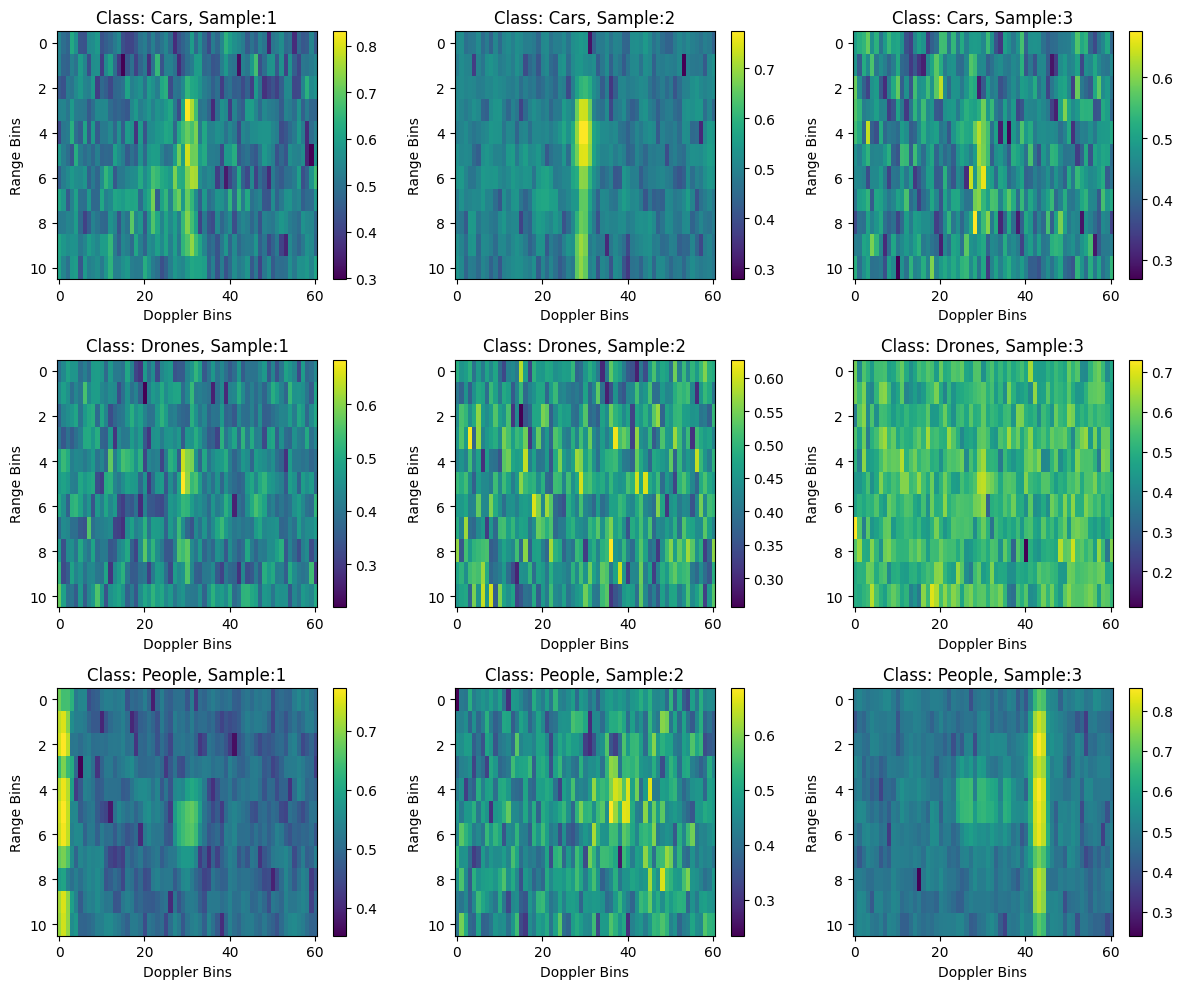

In [10]:
# Get the features and labels from one batch
features, labels = next(iter(train_dataloader))

#plot samples from each class
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
class_name = ['Cars', 'Drones', 'People']

for class_idx in range(3):
  class_mask = labels == class_idx
  class_sample = features[class_mask][:3]

  for sample_idx in range(3):
    ax = axes[class_idx, sample_idx]
    img = class_sample[sample_idx, 0].numpy()
    im = ax.imshow(img, aspect='auto', cmap='viridis')
    ax.set_title(f"Class: {class_name[class_idx]}, Sample:{sample_idx + 1}")
    ax.set_xlabel("Doppler Bins")
    ax.set_ylabel("Range Bins")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [11]:
import torch.nn as nn

class FPGACNN(nn.Module):

  def __init__(self) -> None:
    super(FPGACNN, self).__init__()

    self.feature = nn.Sequential(

        nn.Conv2d(1, 32, kernel_size=(3,5), stride=1, padding=(1,2)),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(32, 64, kernel_size=(3,5), stride=1, padding=(1,2)),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64, 128, kernel_size=(3,5), stride=1, padding=(1,2)),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(896, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 3)
    )

  def forward(self, x):
    x = self.feature(x)
    x = self.classifier(x)
    return x

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = FPGACNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print("\nTraining Setup Complete")

Using device: cpu

Training Setup Complete


In [13]:
def train(model, loader, criterion, optimizer, device):
  model.train()

  running_loss = 0.0
  correct = 0
  total = 0

  for features, labels in tqdm(loader, desc="Training", leave=False):
    features, labels = features.to(device), labels.to(device)

    outputs = model(features)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  epoch_loss = running_loss/len(loader)
  epoch_accumulated = 100 * (correct/total)

  return epoch_loss, epoch_accumulated

def validate(model, loader, criterion, device):
  model.eval()

  running_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():

    for features, labels in tqdm(loader, desc="Validation", leave=False):
      features, labels = features.to(device), labels.to(device)

      outputs = model(features)
      loss = criterion(outputs, labels)

      running_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  epoch_loss = running_loss/len(loader)
  epoch_accumulated = 100 * (correct/total)

  return epoch_loss, epoch_accumulated

train_history = {
    'train_loss':[],
    'train_acc':[],
    'val_loss':[],
    'val_acc':[]
}

num_epochs = 60
best_val_acc = 0.0

for epoch in range(num_epochs):
  print(f"Epoch {epoch + 1} / {num_epochs}")

  train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
  val_loss, val_acc = validate(model, test_dataloader, criterion, device)

  train_history['train_loss'].append(train_loss)
  train_history['train_acc'].append(train_acc)
  train_history['val_loss'].append(val_loss)
  train_history['val_acc'].append(val_acc)

  print(f"Train Loss: {train_loss:.4f} :: Train Accuracy: {train_acc:.2f}%")
  print(f"Val Loss: {val_loss:.4f} :: Val Accuracy: {val_acc:.2f}")

  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(
        {'epoch':epoch,
         'model_state_dict':model.state_dict(),
         'optmizer_state_dict':optimizer.state_dict(),
         'val_acc': val_acc},
        'best_model_params.pth')
    print(f"New best model saved (Val Acc: {best_val_acc:.2f}%)")

  scheduler.step(val_loss)
  print()

print("Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch 1 / 60


Train Loss: 0.4885 :: Train Accuracy: 80.69%
Val Loss: 0.2611 :: Val Accuracy: 89.76
New best model saved (Val Acc: 89.76%)

Epoch 2 / 60


Train Loss: 0.2737 :: Train Accuracy: 89.62%
Val Loss: 0.2103 :: Val Accuracy: 91.16
New best model saved (Val Acc: 91.16%)

Epoch 3 / 60


Train Loss: 0.2433 :: Train Accuracy: 90.36%
Val Loss: 0.1942 :: Val Accuracy: 92.54
New best model saved (Val Acc: 92.54%)

Epoch 4 / 60


Train Loss: 0.2237 :: Train Accuracy: 91.31%
Val Loss: 0.1632 :: Val Accuracy: 93.99
New best model saved (Val Acc: 93.99%)

Epoch 5 / 60


...

Train Loss: 0.1098 :: Train Accuracy: 95.81%
Val Loss: 0.1190 :: Val Accuracy: 95.82
New best model saved (Val Acc: 95.82%)

Epoch 57 / 60


Train Loss: 0.1103 :: Train Accuracy: 95.70%
Val Loss: 0.1190 :: Val Accuracy: 95.57

Epoch 58 / 60


Train Loss: 0.1116 :: Train Accuracy: 95.87%
Val Loss: 0.1195 :: Val Accuracy: 95.48

Epoch 59 / 60


Train Loss: 0.1075 :: Train Accuracy: 95.72%
Val Loss: 0.1178 :: Val Accuracy: 95.28

Epoch 60 / 60


Train Loss: 0.1098 :: Train Accuracy: 95.57%
Val Loss: 0.1169 :: Val Accuracy: 95.42

Training Complete!
Best Validation Accuracy: 95.82%


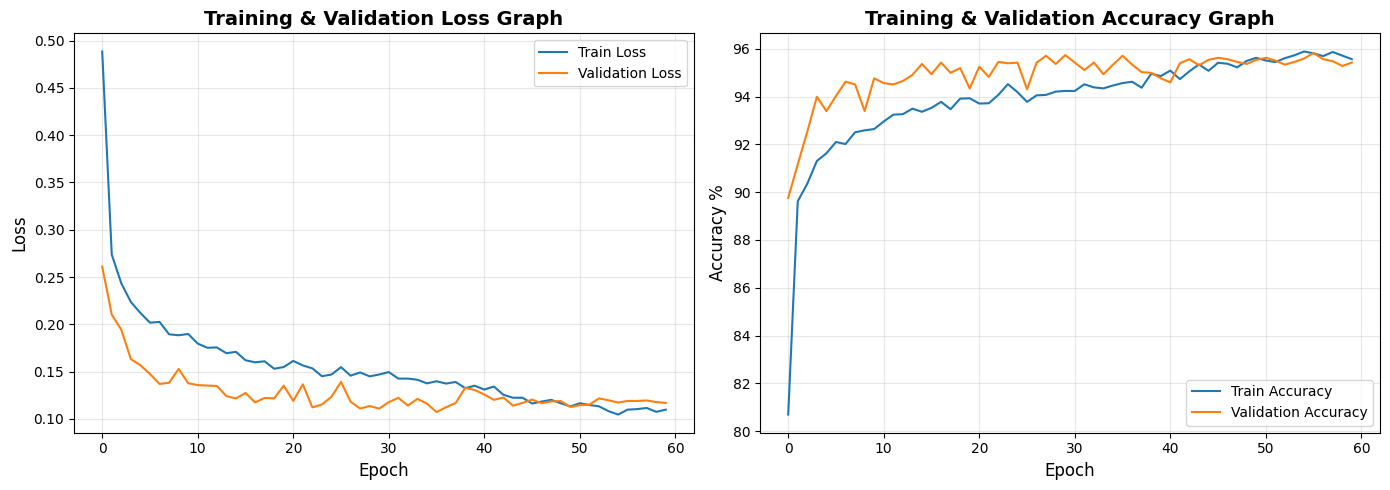

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_history['train_loss'], label='Train Loss')
ax1.plot(train_history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss Graph', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_history['train_acc'], label='Train Accuracy')
ax2.plot(train_history['val_acc'], label='Validation Accuracy')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy %', fontsize=12)
ax2.set_title('Training & Validation Accuracy Graph', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

        Cars     0.9616    0.9187    0.9397      1144
      Drones     0.9092    0.9585    0.9332      1013
      People     0.9948    0.9918    0.9933      1340

    accuracy                         0.9582      3497
   macro avg     0.9552    0.9563    0.9554      3497
weighted avg     0.9591    0.9582    0.9583      3497



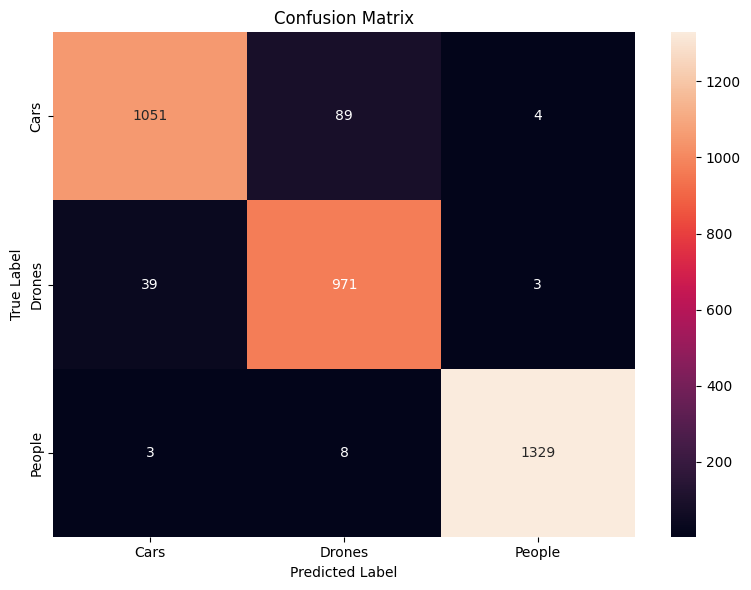

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

checkpoint = torch.load('best_model_params.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
  for features, labels in test_dataloader:
    features = features.to(device)
    outputs = model(features)
    _, predicted = torch.max(outputs, 1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

class_names = ['Cars', 'Drones', 'People']
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()